<div dir="rtl" style="direction:rtl; text-align:right; font-family:'Segoe UI', Arial, sans-serif; font-size:16px; line-height:2; background:#e8f5e9; border-right:6px solid #2e7d32; padding:20px 24px; margin:10px 0; border-radius:8px;">

<h2 style="color:#1b5e20;">تجزئة متقدمة باستخدام K-Means — (اللون + الموضع + الحواف + Gradient)</h2>

<p>يُطوَّر هذا الدفتر مثالَ التجزئة الأساسي بإضافة ميزتين جديدتين لكل بكسل:</p>
<ul>
  <li><strong>Canny Edges:</strong> هل البكسل يقع على حافة في الصورة؟</li>
  <li><strong>Sobel Gradient:</strong> ما مقدار التغيّر في شدة اللون عند هذا البكسل؟</li>
</ul>

<p>هذه الإضافة تجعل K-Means أكثر وعياً بالحدود الحقيقية بين أجزاء الصورة، مما يُحسّن جودة التجزئة.</p>

<table style="width:100%; border-collapse:collapse; text-align:right; direction:rtl; margin-top:10px;">
  <tr style="background:#a5d6a7;">
    <th style="padding:8px; border:1px solid #66bb6a;">الميزة</th>
    <th style="padding:8px; border:1px solid #66bb6a;">المصدر</th>
  </tr>
  <tr><td style="padding:8px; border:1px solid #66bb6a;">X، Y (موضع)</td><td style="padding:8px; border:1px solid #66bb6a;">احداثيات البكسل</td></tr>
  <tr><td style="padding:8px; border:1px solid #66bb6a;">R، G، B (لون)</td><td style="padding:8px; border:1px solid #66bb6a;">قيم اللون المطبّعة</td></tr>
  <tr><td style="padding:8px; border:1px solid #66bb6a;">Gradient Magnitude</td><td style="padding:8px; border:1px solid #66bb6a;">Sobel Filter</td></tr>
  <tr><td style="padding:8px; border:1px solid #66bb6a;">Edge (0 أو 1)</td><td style="padding:8px; border:1px solid #66bb6a;">Canny Edge Detector</td></tr>
</table>

</div>

In [105]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler


<div dir="rtl" style="direction:rtl; text-align:right; font-family:'Segoe UI', Arial, sans-serif; font-size:15px; line-height:1.9; background:#f1f8e9; border-right:5px solid #388e3c; padding:16px 20px; margin:8px 0; border-radius:7px;">

<h3 style="color:#1b5e20;">المكتبات المستخدمة</h3>
<ul>
  <li><strong>cv2 (OpenCV):</strong> قراءة الصور، تحويل الألوان، استخراج الحواف (Canny) وحساب الـ Gradient (Sobel)</li>
  <li><strong>numpy:</strong> بناء مصفوفة الميزات والعمليات الحسابية</li>
  <li><strong>matplotlib:</strong> عرض النتائج البصرية (الصورة الأصلية، الحواف، خريطة التجزئة)</li>
  <li><strong>KMeans:</strong> خوارزمية التجميع غير المراقب</li>
  <li><strong>StandardScaler:</strong> توحيد القيم بحيث يكون المتوسط = 0 والانحراف المعياري = 1، وهذا ضروري لأن ميزات مختلفة (اللون، الموضع، الـ Gradient) تملك نطاقات قيم مختلفة</li>
</ul>

</div>

In [136]:
# الإعدادات
# =========================

IMAGE_PATH = "image.png"   # اسم الصورة
IMAGE_SIZE = (500, 350)    # لتسريع التنفيذ
K = 8                      # عدد العناقيد
ALPHA = 0.35               # شفافية الطبقة الملونة



<div dir="rtl" style="direction:rtl; text-align:right; font-family:'Segoe UI', Arial, sans-serif; font-size:15px; line-height:1.9; background:#e3f2fd; border-right:5px solid #1565c0; padding:16px 20px; margin:8px 0; border-radius:7px;">

<h3 style="color:#0d47a1;">الإعدادات العامة</h3>
<table style="width:100%; border-collapse:collapse; text-align:right; direction:rtl;">
  <tr style="background:#bbdefb;">
    <th style="padding:7px; border:1px solid #90caf9;">المتغير</th>
    <th style="padding:7px; border:1px solid #90caf9;">القيمة</th>
    <th style="padding:7px; border:1px solid #90caf9;">الشرح</th>
  </tr>
  <tr><td style="padding:7px; border:1px solid #90caf9;"><code>IMAGE_SIZE</code></td><td style="padding:7px; border:1px solid #90caf9;">(500, 350)</td><td style="padding:7px; border:1px solid #90caf9;">حجم أكبر من المثال الأول لنتائج أدق</td></tr>
  <tr><td style="padding:7px; border:1px solid #90caf9;"><code>K</code></td><td style="padding:7px; border:1px solid #90caf9;">6</td><td style="padding:7px; border:1px solid #90caf9;">عدد المجموعات (Clusters)</td></tr>
  <tr><td style="padding:7px; border:1px solid #90caf9;"><code>ALPHA</code></td><td style="padding:7px; border:1px solid #90caf9;">0.35</td><td style="padding:7px; border:1px solid #90caf9;">درجة شفافية طبقة الألوان على الصورة</td></tr>
</table>

</div>

In [139]:
# =========================
# قراءة الصورة
# =========================

image_bgr = cv2.imread(IMAGE_PATH)

if image_bgr is None:
    raise Exception("لم يتم العثور على الصورة. تأكد من اسم الملف والمسار.")

image_bgr = cv2.resize(image_bgr, IMAGE_SIZE)
image = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

height, width, _ = image.shape

In [141]:

# =========================
# استخراج الحواف والـ Gradient
# =========================

gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

# Canny Edges
edges = cv2.Canny(gray, threshold1=80, threshold2=180)
edges_norm = edges / 255.0

# Sobel Gradient Magnitude
sobel_x = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
sobel_y = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)

gradient = np.sqrt(sobel_x ** 2 + sobel_y ** 2)

if gradient.max() > 0:
    gradient_norm = gradient / gradient.max()
else:
    gradient_norm = gradient



<div dir="rtl" style="direction:rtl; text-align:right; font-family:'Segoe UI', Arial, sans-serif; font-size:15px; line-height:1.9; background:#fce4ec; border-right:5px solid #c62828; padding:16px 20px; margin:8px 0; border-radius:7px;">

<h3 style="color:#b71c1c;">استخراج الحواف والـ Gradient</h3>

<p><strong>أولاً — Canny Edge Detector:</strong></p>
<ul>
  <li>يكتشف الحواف الحادة في الصورة باستخدام حدّي التعتيم (threshold1=80، threshold2=180)</li>
  <li>ناتجه: صورة ثنائية — <code>0</code> للبكسلات غير الحافية، <code>255</code> للحافية</li>
  <li>نُطبّعها بقسمتها على 255 لتصبح في النطاق [0, 1]</li>
</ul>

<p><strong>ثانياً — Sobel Gradient:</strong></p>
<ul>
  <li><code>sobel_x</code>: يقيس التغيّر الأفقي في شدة الصورة</li>
  <li><code>sobel_y</code>: يقيس التغيّر الرأسي في شدة الصورة</li>
  <li><strong>Gradient Magnitude</strong> = √(sobel_x² + sobel_y²) — يُمثّل مقدار حدّة الحافة بشكل مستقل عن اتجاهها</li>
</ul>

<p><strong>الهدف:</strong> هذه الميزات تجعل K-Means يُفرّق بين المناطق ذات الحواف الحادة والمناطق الملساء، مما يُحسّن حدود التجزئة.</p>

</div>

In [144]:
# =========================
# بناء Feature Matrix
# =========================

features = []

for y in range(height):
    for x in range(width):
        r, g, b = image[y, x]

        feature_vector = [
            x / width,
            y / height,
            r / 255.0,
            g / 255.0,
            b / 255.0,
            gradient_norm[y, x],
            edges_norm[y, x],
        ]

        features.append(feature_vector)

features = np.array(features)

print("Feature matrix shape:", features.shape)


Feature matrix shape: (175000, 7)


<div dir="rtl" style="direction:rtl; text-align:right; font-family:'Segoe UI', Arial, sans-serif; font-size:15px; line-height:1.9; background:#fff3e0; border-right:5px solid #e65100; padding:16px 20px; margin:8px 0; border-radius:7px;">

<h3 style="color:#bf360c;">بناء مصفوفة الميزات (7 ميزات لكل بكسل)</h3>
<p>يمثّل كل بكسل الآن بمتجه من <strong>7 ميزات</strong> — أكثر تفصيلاً من المثال السابق:</p>

<table style="width:100%; border-collapse:collapse; text-align:right; direction:rtl;">
  <tr style="background:#ffe0b2;">
    <th style="padding:7px; border:1px solid #ffb74d;">#</th>
    <th style="padding:7px; border:1px solid #ffb74d;">الميزة</th>
    <th style="padding:7px; border:1px solid #ffb74d;">المصدر</th>
  </tr>
  <tr><td style="padding:7px; border:1px solid #ffb74d;">1</td><td style="padding:7px; border:1px solid #ffb74d;"><code>x / width</code></td><td style="padding:7px; border:1px solid #ffb74d;">موضع أفقي</td></tr>
  <tr><td style="padding:7px; border:1px solid #ffb74d;">2</td><td style="padding:7px; border:1px solid #ffb74d;"><code>y / height</code></td><td style="padding:7px; border:1px solid #ffb74d;">موضع رأسي</td></tr>
  <tr><td style="padding:7px; border:1px solid #ffb74d;">3</td><td style="padding:7px; border:1px solid #ffb74d;"><code>r / 255</code></td><td style="padding:7px; border:1px solid #ffb74d;">قناة حمراء</td></tr>
  <tr><td style="padding:7px; border:1px solid #ffb74d;">4</td><td style="padding:7px; border:1px solid #ffb74d;"><code>g / 255</code></td><td style="padding:7px; border:1px solid #ffb74d;">قناة خضراء</td></tr>
  <tr><td style="padding:7px; border:1px solid #ffb74d;">5</td><td style="padding:7px; border:1px solid #ffb74d;"><code>b / 255</code></td><td style="padding:7px; border:1px solid #ffb74d;">قناة زرقاء</td></tr>
  <tr><td style="padding:7px; border:1px solid #ffb74d;">6</td><td style="padding:7px; border:1px solid #ffb74d;"><code>gradient_norm</code></td><td style="padding:7px; border:1px solid #ffb74d;">Sobel Gradient</td></tr>
  <tr><td style="padding:7px; border:1px solid #ffb74d;">7</td><td style="padding:7px; border:1px solid #ffb74d;"><code>edges_norm</code></td><td style="padding:7px; border:1px solid #ffb74d;">Canny Edges</td></tr>
</table>

<p style="margin-top:10px;">الناتج: مصفوفة شكلها <code>(175000, 7)</code> حيث 175000 = 500 × 350 بكسل.</p>

</div>

In [146]:
# =========================
# Scaling
# =========================

scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)



<div dir="rtl" style="direction:rtl; text-align:right; font-family:'Segoe UI', Arial, sans-serif; font-size:15px; line-height:1.9; background:#f3e5f5; border-right:5px solid #6a1b9a; padding:16px 20px; margin:8px 0; border-radius:7px;">

<h3 style="color:#4a148c;">توحيد الميزات — StandardScaler</h3>

<p><strong>لماذا نحتاج StandardScaler هنا؟</strong></p>
<p>ميزاتنا السبع تملك نطاقات مختلفة، وهذا يؤثر سلباً على K-Means:</p>
<ul>
  <li>الـ Gradient قد يصل إلى قيم كبيرة جداً مقارنةً بقيم اللون [0,1]</li>
  <li>بدون توحيد، ستُهيمن الميزات ذات النطاق الأوسع على حسابات المسافة</li>
</ul>

<p><strong>ما يفعله StandardScaler:</strong> يحوّل كل ميزة بحيث يكون <strong>متوسطها = 0</strong> و<strong>انحرافها المعياري = 1</strong>:
<br><code>z = (x − mean) / std</code></p>

<p>بعد التوحيد، جميع الميزات السبع تُساهم بشكل متساوٍ في حسابات المسافة الإقليدية داخل K-Means.</p>

</div>

In [148]:
# =========================
# تطبيق K-Means
# =========================

kmeans = KMeans(
    n_clusters=K,
    random_state=42,
    n_init=10
)

labels = kmeans.fit_predict(features_scaled)

segmented = labels.reshape(height, width)



In [149]:
# =========================
# ألوان العناقيد
# =========================

colors = np.array([
    [255, 0, 0],      # أحمر
    [0, 255, 0],      # أخضر
    [0, 0, 255],      # أزرق
    [255, 255, 0],    # أصفر
    [255, 0, 255],    # بنفسجي
    [0, 255, 255],    # سماوي
    [255, 128, 0],    # برتقالي
    [128, 0, 255],    # بنفسجي غامق
], dtype=np.uint8)



In [150]:
# =========================
# إنشاء Overlay شفاف
# =========================

overlay = image.copy()

for cluster_id in range(K):
    mask = segmented == cluster_id
    color = colors[cluster_id % len(colors)]

    overlay[mask] = (
        (1 - ALPHA) * overlay[mask] +
        ALPHA * color
    ).astype(np.uint8)




In [151]:
# =========================
# إنشاء صورة ملونة للتقسيم فقط
# =========================

segmentation_map = np.zeros_like(image)

for cluster_id in range(K):
    mask = segmented == cluster_id
    segmentation_map[mask] = colors[cluster_id % len(colors)]



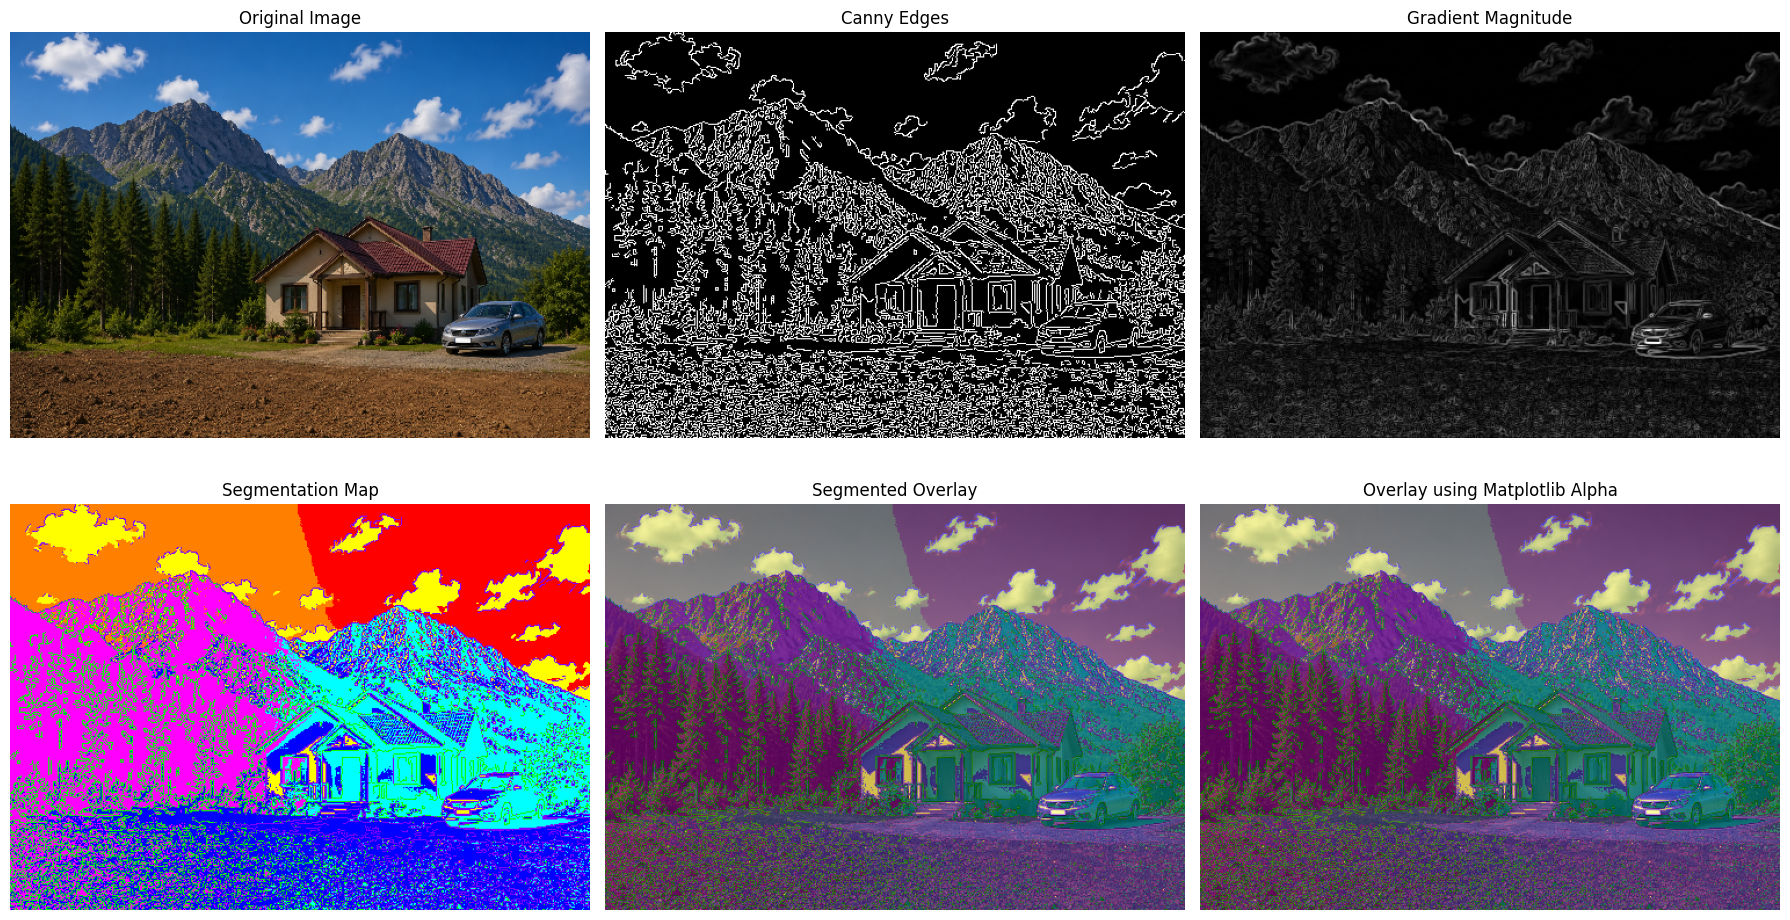

In [154]:
# =========================
# عرض النتائج
# =========================

plt.figure(figsize=(18, 10))

plt.subplot(2, 3, 1)
plt.imshow(image)
plt.title("Original Image")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(edges, cmap="gray")
plt.title("Canny Edges")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(gradient_norm, cmap="gray")
plt.title("Gradient Magnitude")
plt.axis("off")

plt.subplot(2, 3, 4)
plt.imshow(segmentation_map)
plt.title("Segmentation Map")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(overlay)
plt.title("Segmented Overlay")
plt.axis("off")

plt.subplot(2, 3, 6)
plt.imshow(image)
plt.imshow(segmentation_map, alpha=ALPHA)
plt.title("Overlay using Matplotlib Alpha")
plt.axis("off")

plt.tight_layout()
plt.show()



In [155]:
# =========================
# حفظ النتائج
# =========================

cv2.imwrite("edges.jpg", edges)
cv2.imwrite("gradient.jpg", (gradient_norm * 255).astype(np.uint8))
cv2.imwrite("segmentation_map.jpg", cv2.cvtColor(segmentation_map, cv2.COLOR_RGB2BGR))
cv2.imwrite("segmented_overlay.jpg", cv2.cvtColor(overlay, cv2.COLOR_RGB2BGR))

print("تم حفظ النتائج:")
print("edges.jpg")
print("gradient.jpg")
print("segmentation_map.jpg")
print("segmented_overlay.jpg")

تم حفظ النتائج:
edges.jpg
gradient.jpg
segmentation_map.jpg
segmented_overlay.jpg
